In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
# Path to your extracted entropy features
MANIFEST_PATH = "Entropy_DTW_features/_manifest_entropy_dtw.csv"

# --- Load manifest ---
df = pd.read_csv(MANIFEST_PATH)
print(f"Loaded {len(df)} feature entries")

Loaded 3300 feature entries


In [ ]:
# Path to your extracted entropy features
MANIFEST_PATH = "Entropy_DTW_features/_manifest_entropy_dtw.csv"

# --- Load manifest ---
df = pd.read_csv(MANIFEST_PATH)
print(f"Loaded {len(df)} feature entries")

Loaded 3300 feature entries
Classes: ['belly pain' 'burping' 'cold_hot' 'discomfort' 'hungry' 'tired']
Final input shape: (3300, 219, 18), Classes: 6


In [ ]:
# -----------------------------
# K-Fold Configuration
# -----------------------------
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
fold_accuracies = []

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 1️⃣ Split into train + temp (80/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# 2️⃣ Split temp into validation and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)
from tensorflow.keras.utils import to_categorical

y_test = to_categorical(y_test, num_classes=6)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print("Test samples:", X_test.shape)


Training samples: (2640, 219, 18)
Validation samples: (330, 219, 18)
Test samples: (330, 219, 18)


In [7]:
print("y_test shape:", y_test.shape)
print("Unique labels in y_test:", np.unique(y_test))


y_test shape: (330, 6)
Unique labels in y_test: [0. 1.]


In [ ]:
print("Train samples:", len(X_train))
print("Val samples:", len(X_val))
print("Test samples:", len(X_test))

print("Val class distribution:")
print(np.bincount(y_val))

print("Test class distribution:")
print(np.bincount(np.argmax(y_test, axis=1)))




Train samples: 2640
Val samples: 330
Test samples: 330
Val class distribution:
[55 55 55 55 55 55]
Test class distribution:
[55 55 55 55 55 55]


: 

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

def build_entropy_cnn_bilstm_model(input_shape, num_classes):
    model = Sequential()

    # ===== CNN BLOCK =====
    model.add(Conv1D(
        filters=64,
        kernel_size=7,          # wider kernel for entropy trends
        activation='relu',
        padding='same',
        input_shape=input_shape
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu',
        padding='same'
    ))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.4))

    # ===== BiLSTM BLOCK =====
    model.add(
        Bidirectional(
            LSTM(128, return_sequences=False)
        )
    )
    model.add(Dropout(0.4))

    # ===== CLASSIFIER =====
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    return model


In [12]:
model = build_entropy_cnn_bilstm_model(
    input_shape=(X_padded.shape[1], X_padded.shape[2]),
    num_classes=num_classes
)

model.summary()


c:\Users\91720\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 219, 64)        │         8,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 219, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 109, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 109, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 54, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,990 (1.26 MB)

 Trainable params: 329,606 (1.26 MB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_padded, y)):
    print(f"\n🌀 Fold {fold+1}")

    X_train, X_val = X_padded[train_idx], X_padded[val_idx]
    y_train, y_val = y_cat[train_idx], y_cat[val_idx]

    model = build_entropy_cnn_bilstm_model(
        input_shape=(X_padded.shape[1], X_padded.shape[2]),
        num_classes=num_classes
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            patience=5,
            factor=0.5,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        X_train, y_train,
        epochs=40,              # ↑ CNN+LSTM needs more room
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )

    val_acc = model.evaluate(X_val, y_val, verbose=0)[1]
    cv_accuracies.append(val_acc)

    print(f"✅ Fold {fold+1} Accuracy: {val_acc:.4f}")

print(
    f"\n📊 Average CV Accuracy: "
    f"{np.mean(cv_accuracies):.4f} ± {np.std(cv_accuracies):.4f}"
)



🌀 Fold 1


c:\Users\91720\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 32s 198ms/step - accuracy: 0.2027 - loss: 1.7826 - val_accuracy: 0.2212 - val_loss: 1.7552 - learning_rate: 1.0000e-04
Epoch 2/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.2515 - loss: 1.7259 - val_accuracy: 0.2530 - val_loss: 1.7320 - learning_rate: 1.0000e-04
Epoch 3/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.2614 - loss: 1.7065 - val_accuracy: 0.2727 - val_loss: 1.7103 - learning_rate: 1.0000e-04
Epoch 4/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.2807 - loss: 1.6873 - val_accuracy: 0.2879 - val_loss: 1.6945 - learning_rate: 1.0000e-04
Epoch 5/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 181ms/step - accuracy: 0.3057 - loss: 1.6646 - val_accuracy: 0.3242 - val_loss: 1.6730 - learning_rate: 1.0000e-04
Epoch 6/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 175ms/step - accuracy: 0.3174 - loss: 1.6412 - val_accuracy: 0.3167 - val_loss: 1.6607 - learning_rate: 1.0000e-04
Epoch 7/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - acc

In [ ]:
final_model = build_entropy_cnn_bilstm_model(
    input_shape=(X_padded.shape[1], X_padded.shape[2]),
    num_classes=num_classes
)
'''
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6)
]'''

history = final_model.fit(
    X_train,          # from your train/val/test split
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    verbose=1
)

Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.2216 - loss: 1.7792 - val_accuracy: 0.2545 - val_loss: 1.7492
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.2640 - loss: 1.7211 - val_accuracy: 0.2545 - val_loss: 1.7236
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - accuracy: 0.2742 - loss: 1.7021 - val_accuracy: 0.2773 - val_loss: 1.6988
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.2833 - loss: 1.6774 - val_accuracy: 0.3091 - val_loss: 1.6801
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 151ms/step - accuracy: 0.3068 - loss: 1.6569 - val_accuracy: 0.3197 - val_loss: 1.6688
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - accuracy: 0.3239 - loss: 1.6422 - val_accuracy: 0.3106 - val_loss: 1.6640
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.3455 - loss: 1.6153 - val_accuracy: 0.3333 - val_loss: 1.6530
Epoch 8/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.3625 - loss: 1.5972 - val_accu

In [15]:
print("\n--- Train Evaluation ---")
train_loss, train_acc = final_model.evaluate(
    X_train, y_train, verbose=0        # already one-hot
)

print("\n--- Validation Evaluation ---")
val_loss, val_acc = final_model.evaluate(
    X_val, y_val, verbose=0            # already one-hot
)

print("\n--- Test Evaluation ---")
test_loss, test_acc = final_model.evaluate(
    X_test, y_test, verbose=0      # FIXED
)

print(f"Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f}")
print(f"Val   Acc: {val_acc:.4f}, Loss: {val_loss:.4f}")
print(f"Test  Acc: {test_acc:.4f}, Loss: {test_loss:.4f}")



--- Train Evaluation ---

--- Validation Evaluation ---

--- Test Evaluation ---
Train Acc: 0.8621, Loss: 0.7117
Val   Acc: 0.4515, Loss: 1.6443
Test  Acc: 0.7788, Loss: 0.9067


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step

Classification Report:
              precision    recall  f1-score   support

  belly pain       0.68      0.82      0.74        55
     burping       0.64      0.67      0.65        55
    cold_hot       0.58      0.47      0.52        55
  discomfort       0.64      0.49      0.56        55
      hungry       0.45      0.45      0.45        55
       tired       0.58      0.67      0.62        55

    accuracy                           0.60       330
   macro avg       0.60      0.60      0.59       330
weighted avg       0.60      0.60      0.59       330



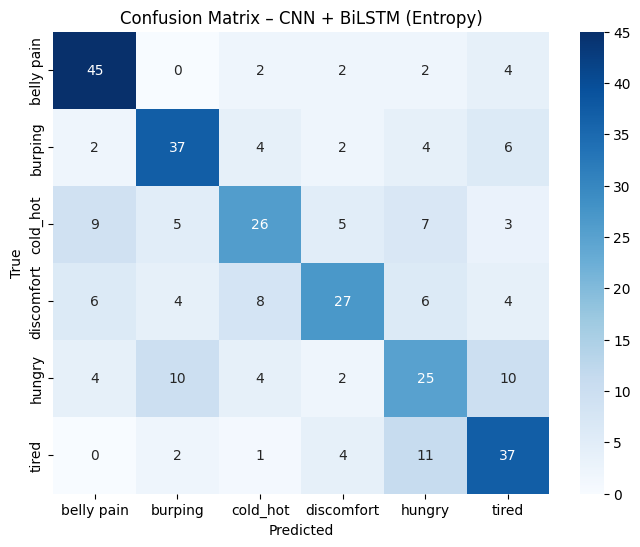

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = final_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_test_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – CNN + BiLSTM (Entropy)")
plt.show()


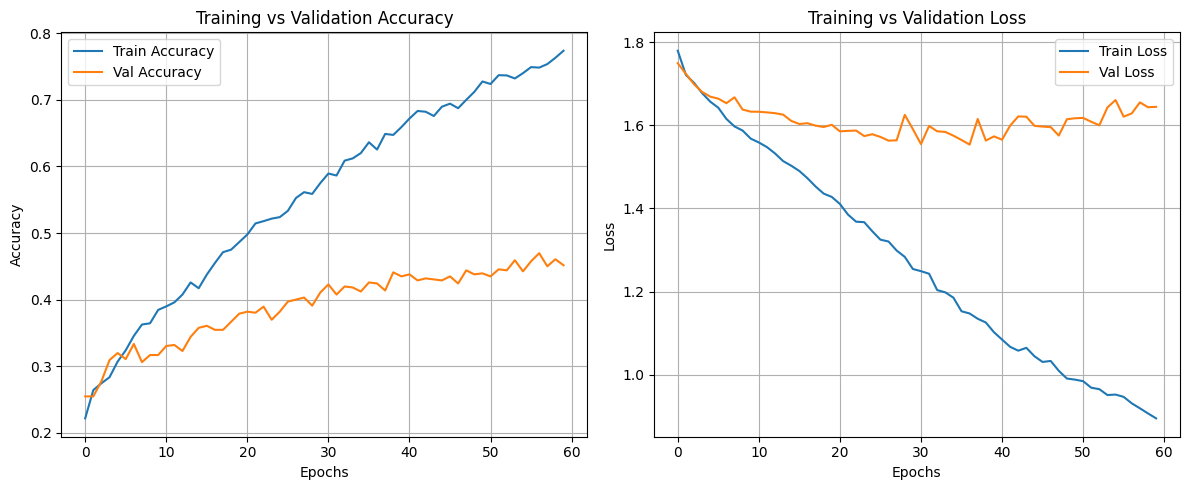

In [17]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [18]:
final_model.save("entropy_dtw_cnn_bilstm_model2.h5")
print("✅ Final CNN+BiLSTM model saved")

✅ Final CNN+BiLSTM model saved


In [19]:
from collections import Counter

print("Train:", Counter(y_train.argmax(axis=1)))
print("Val  :", Counter(y_val.argmax(axis=1)))
print("Test :", Counter(y_test.argmax(axis=1)))


Train: Counter({np.int64(0): 440, np.int64(1): 440, np.int64(2): 440, np.int64(3): 440, np.int64(4): 440, np.int64(5): 440})
Val  : Counter({np.int64(0): 110, np.int64(1): 110, np.int64(2): 110, np.int64(3): 110, np.int64(4): 110, np.int64(5): 110})
Test : Counter({np.int64(3): 55, np.int64(0): 55, np.int64(2): 55, np.int64(1): 55, np.int64(4): 55, np.int64(5): 55})


In [21]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict
y_pred = final_model.predict(X_test, verbose=0)
y_pred_classes = y_pred.argmax(axis=1)

# Classification report
print(classification_report(
    y_test.argmax(axis=1),
    y_pred_classes,
    target_names=label_encoder.classes_
))


              precision    recall  f1-score   support

  belly pain       0.81      0.95      0.87        55
     burping       0.78      0.89      0.83        55
    cold_hot       0.78      0.85      0.82        55
  discomfort       0.78      0.82      0.80        55
      hungry       0.68      0.38      0.49        55
       tired       0.80      0.78      0.79        55

    accuracy                           0.78       330
   macro avg       0.77      0.78      0.77       330
weighted avg       0.77      0.78      0.77       330

